In [7]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import tkinter as tk
from tkinter import ttk, filedialog
from PIL import ImageTk, Image

In [3]:
def scrape_images_from_url(url, save_directory="images"):
    """
    Scrapes all images from a given URL and saves them to the specified directory.

    :param url: URL of the webpage to scrape images from.
    :param save_directory: Directory where images will be saved.
    """
    try:
        # Send a GET request to the URL
        response = requests.get(url)
        response.raise_for_status()  # Raise an exception for HTTP errors

        # Parse the HTML content
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all image tags
        img_tags = soup.find_all('img')

        # Create directory to save images
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)

        print(f"Found {len(img_tags)} images. Starting download...")

        # Download and save each image
        image_paths = []
        for i, img_tag in enumerate(img_tags):
            # Get the image URL
            img_url = img_tag.get('src')
            if not img_url:
                continue

            # Handle relative URLs
            img_url = urljoin(url, img_url)

            # Skip .svg images
            if img_url.lower().endswith('.svg'):
                print(f"Skipping SVG image: {img_url}")
                continue

            try:
                # Get the image content
                img_response = requests.get(img_url, stream=True)
                img_response.raise_for_status()

                # Create a unique filename
                img_filename = os.path.join(save_directory, f"image_{i + 1}.jpg")

                # Save the image
                with open(img_filename, 'wb') as img_file:
                    for chunk in img_response.iter_content(1024):
                        img_file.write(chunk)

                image_paths.append(img_filename)
                print(f"Downloaded: {img_filename}")
            except requests.exceptions.RequestException as e:
                print(f"Failed to download {img_url}: {e}")

        print("Image scraping completed!")
        return image_paths

    except requests.exceptions.RequestException as e:
        print(f"Failed to fetch URL: {e}")
        return []

In [8]:
def read_images_from_folder(folder_path):
    """
    Reads all image files from the specified folder.

    :param folder_path: Path to the folder containing images.
    :return: List of image file paths.
    """
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
    image_paths = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            if os.path.splitext(file)[1].lower() in valid_extensions:
                image_paths.append(os.path.join(root, file))

    return image_paths

In [10]:
def get_top_results_from_folder(text, folder_path, top_n=5):
    """
    Returns the top N images ranked by similarity to the input text from a folder of images.

    :param text: Input text for similarity ranking.
    :param folder_path: Path to the folder containing images.
    :param top_n: Number of top results to return.
    """
    # Load CLIP model and processor
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    # Read images from the folder
    image_paths = read_images_from_folder(folder_path)
    images = [Image.open(img_path) for img_path in image_paths]

    inputs = processor(text=[text], images=images, return_tensors="pt", padding=True)

    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image  # Image-text similarity scores
    probs = logits_per_image.softmax(dim=0).squeeze().tolist()

    # Ensure probs is a flat list if there's only one image
    if isinstance(probs, float):
        probs = [probs]

    # Sort images by similarity probability
    sorted_indices = sorted(range(len(probs)), key=lambda i: probs[i], reverse=True)

    # Return top N results
    return [(image_paths[idx], probs[idx]) for idx in sorted_indices[:top_n]]

In [11]:
def display_top_results(results):
    """
    Displays the top results as images with their similarity scores.

    :param results: List of tuples containing image paths and their scores.
    """
    plt.figure(figsize=(15, 5))
    for i, (img_path, score) in enumerate(results):
        img = Image.open(img_path)
        plt.subplot(1, len(results), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Score: {score:.2f}")
    plt.tight_layout()
    plt.show()

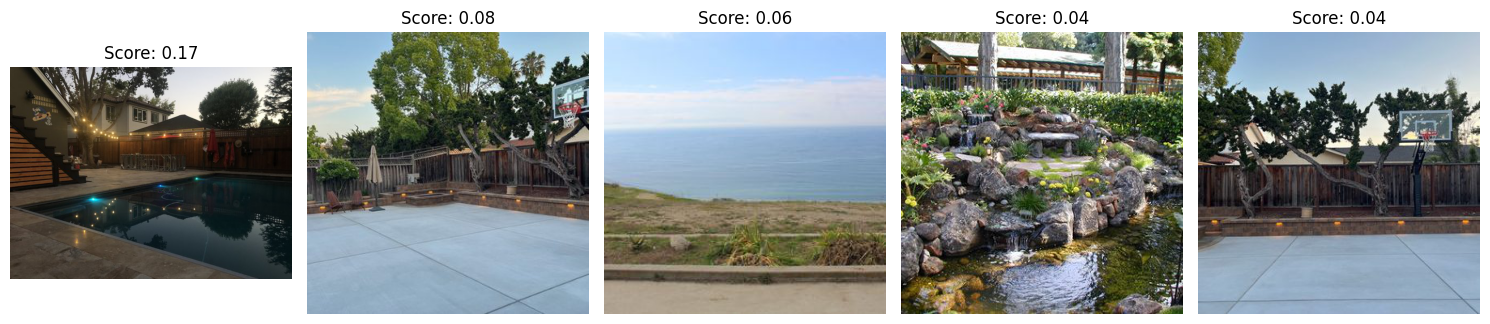

In [15]:
# Example usage
if __name__ == "__main__":
    folder_path = "./images"  # Replace with the path to your folder
    user_input_text = "A photo of beautiful barkyard"

    if os.path.exists(folder_path):
        results = get_top_results_from_folder(user_input_text, folder_path)
        display_top_results(results)